In [1]:
"""
Preprocessing Pipeline — Standards + Arxiv for Continual Pretraining
=====================================================================
Produces a HuggingFace dataset ready for TRL SFTTrainer / next-token prediction.

Run:
    pip install datasets tqdm

    python preprocess.py \\
        --input  /path/to/tele-data/train \\
        --output ./tele-preprocessed \\
        --max-seq-len 2048 \\
        --standards-upsample 8 \\
        --eval-ratio 0.05

Output:
    ./tele-preprocessed/
        train/          HuggingFace Arrow dataset
        eval/           HuggingFace Arrow dataset
        stats.json      preprocessing report
"""

import argparse
import json
import os
import re
import random
from collections import defaultdict

from datasets import load_from_disk, Dataset
from tqdm import tqdm

# ---------------------------------------------------------------------------
# Constants
# ---------------------------------------------------------------------------

# LLaMA 3 special tokens
BOS = "<|begin_of_text|>"
EOS = "<|end_of_text|>"

# Clause heading pattern: one or more digit groups separated by dots, then a tab
# Matches: "1\t", "3.1\t", "5.2.1\t", "5.2.1.4\t"
CLAUSE_RE = re.compile(r"^(\d+(?:\.\d+)*)\t(.+)$")

# Header boilerplate patterns — lines to strip before clause 1
HEADER_STOP_RE = re.compile(r"^\d+\t")   # first real clause heading

# Approximate tokens: word count / 0.75
def approx_tokens(text: str) -> int:
    return int(len(text.split()) / 0.75)

# ---------------------------------------------------------------------------
# Standards preprocessing
# ---------------------------------------------------------------------------

def parse_metadata(raw: str) -> dict:
    """Parse metadata JSON string. Returns {} on failure."""
    try:
        return json.loads(raw)
    except Exception:
        return {}

def strip_header(text: str) -> str:
    """
    Remove everything before the first top-level clause heading (e.g. '1\tScope').
    Keeps the clause heading itself.
    """
    lines = text.splitlines()
    for i, line in enumerate(lines):
        if HEADER_STOP_RE.match(line.strip()):
            return "\n".join(lines[i:])
    # No clause found — return as-is (will be handled downstream)
    return text

def split_into_clauses(text: str) -> list[dict]:
    """
    Split document text into clause chunks.
    Each chunk = {"clause_num": "5.2.1", "title": "Service Description", "body": "..."}
    """
    lines = text.splitlines()
    clauses = []
    current = None

    for line in lines:
        stripped = line.strip()
        m = CLAUSE_RE.match(stripped)
        if m:
            # Save previous clause
            if current is not None:
                clauses.append(current)
            current = {
                "clause_num": m.group(1),
                "title":      m.group(2).strip(),
                "body_lines": [],
            }
        else:
            if current is not None:
                current["body_lines"].append(line)

    # Don't forget the last clause
    if current is not None:
        clauses.append(current)

    # Finalise body text
    result = []
    for c in clauses:
        body = "\n".join(c["body_lines"]).strip()
        result.append({
            "clause_num": c["clause_num"],
            "title":      c["title"],
            "body":       body,
        })
    return result

def merge_short_clauses(clauses: list[dict], min_tokens: int = 200) -> list[dict]:
    """
    Merge consecutive clauses that are too short into the next clause.
    Avoids tiny fragments like "3.1 Definitions\n(void)" becoming standalone examples.
    """
    merged = []
    buffer = None

    for clause in clauses:
        tokens = approx_tokens(
            f"{clause['clause_num']}\t{clause['title']}\n{clause['body']}"
        )
        if buffer is None:
            buffer = clause.copy()
            buffer["_tokens"] = tokens
        else:
            if buffer["_tokens"] < min_tokens:
                # Merge current into buffer
                buffer["body"] = (
                    buffer["body"]
                    + f"\n\n{clause['clause_num']}\t{clause['title']}\n{clause['body']}"
                ).strip()
                buffer["_tokens"] += tokens
            else:
                merged.append(buffer)
                buffer = clause.copy()
                buffer["_tokens"] = tokens

    if buffer is not None:
        merged.append(buffer)

    return merged

def format_standard_chunk(clause: dict, meta: dict) -> str:
    """
    Format a clause chunk as plain text for next-token prediction.
    Includes a short document header so the model knows the context.
    """
    series   = meta.get("series",    meta.get("Series",    ""))
    release  = meta.get("release",   meta.get("Release",   ""))
    filename = meta.get("file_name", meta.get("File_name", ""))

    # Reconstruct TS number from file_name e.g. "29161-c00" -> "29.161"
    ts_number = ""
    if filename:
        base = filename.split("-")[0]  # "29161"
        if len(base) >= 5:
            ts_number = f"{base[:2]}.{base[2:]}"   # "29.161"

    header = f"3GPP TS {ts_number} Release {release} Series {series}"
    clause_text = f"{clause['clause_num']}\t{clause['title']}\n{clause['body']}"

    return f"{BOS}{header}\n\n{clause_text}{EOS}"

def process_standard_doc(record: dict, max_tokens: int = 2048) -> list[str]:
    """
    Full pipeline for one standards document.
    Returns list of formatted text chunks ready for training.
    """
    text     = record.get("content", "") or ""
    meta     = parse_metadata(record.get("metadata", "") or "{}")

    # 1. Strip header boilerplate
    text = strip_header(text)
    if not text.strip():
        return []

    # 2. Split into clauses
    clauses = split_into_clauses(text)
    if not clauses:
        return []

    # 3. Merge short clauses
    clauses = merge_short_clauses(clauses, min_tokens=200)

    # 4. Format + truncate
    chunks = []
    for clause in clauses:
        formatted = format_standard_chunk(clause, meta)
        # Hard truncate by words if over limit (rare for clause-split docs)
        tokens = approx_tokens(formatted)
        if tokens > max_tokens:
            # Truncate body word by word
            words      = formatted.split()
            word_limit = int(max_tokens * 0.75)
            formatted  = " ".join(words[:word_limit]) + f" {EOS}"
        chunks.append(formatted)

    return chunks

# ---------------------------------------------------------------------------
# Arxiv preprocessing
# ---------------------------------------------------------------------------

def chunk_text(text: str, max_tokens: int = 2048, overlap_tokens: int = 0) -> list[str]:
    """
    Simple word-based chunking for arxiv documents.
    No clause structure — just sliding window over words.
    overlap_tokens: words to repeat at the start of each chunk for context continuity.
    """
    words      = text.split()
    word_limit = int(max_tokens * 0.75)
    overlap    = int(overlap_tokens * 0.75)
    chunks     = []
    start      = 0

    while start < len(words):
        end   = min(start + word_limit, len(words))
        chunk = " ".join(words[start:end])
        chunks.append(chunk)
        if end == len(words):
            break
        start = end - overlap if overlap > 0 else end

    return chunks

def format_arxiv_chunk(chunk: str, meta: dict) -> str:
    """Format an arxiv chunk for next-token prediction."""
    title = meta.get("title", meta.get("Title", ""))
    prefix = f"arXiv: {title}\n\n" if title else ""
    return f"{BOS}{prefix}{chunk}{EOS}"

def process_arxiv_doc(record: dict, max_tokens: int = 2048) -> list[str]:
    """Full pipeline for one arxiv document."""
    text = record.get("content", "") or ""
    meta = parse_metadata(record.get("metadata", "") or "{}")

    if not text.strip():
        return []

    raw_chunks = chunk_text(text, max_tokens=max_tokens)
    return [format_arxiv_chunk(c, meta) for c in raw_chunks if c.strip()]

# ---------------------------------------------------------------------------
# Main pipeline
# ---------------------------------------------------------------------------

def run(
    input_path:         str,
    output_path:        str,
    max_seq_len:        int   = 2048,
    standards_upsample: int   = 8,
    eval_ratio:         float = 0.05,
    seed:               int   = 42,
):
    random.seed(seed)

    print(f"\n{'='*60}")
    print(f"  Tele-Data Preprocessing Pipeline")
    print(f"{'='*60}")
    print(f"  Input          : {input_path}")
    print(f"  Output         : {output_path}")
    print(f"  Max seq len    : {max_seq_len} tokens")
    print(f"  Standards ×    : {standards_upsample}")
    print(f"  Eval ratio     : {eval_ratio}")
    print()

    ds = load_from_disk(input_path)
    print(f"  Loaded {len(ds):,} total examples")

    # ── Filter to standards + arxiv ────────────────────────────────────────
    print(f"\n  Filtering to standards + arxiv...")
    ds_standards = ds.filter(lambda x: x["category"] == "standard", num_proc=4)
    ds_arxiv     = ds.filter(lambda x: x["category"] == "arxiv",    num_proc=4)
    print(f"  standards : {len(ds_standards):,}")
    print(f"  arxiv     : {len(ds_arxiv):,}")

    # ── Process standards ─────────────────────────────────────────────────
    print(f"\n  Processing standards documents...")
    std_chunks = []
    std_skipped = 0

    for record in tqdm(ds_standards, desc="  standards"):
        chunks = process_standard_doc(record, max_tokens=max_seq_len)
        if chunks:
            std_chunks.extend(chunks)
        else:
            std_skipped += 1

    print(f"  → {len(std_chunks):,} chunks from {len(ds_standards):,} docs "
          f"({std_skipped} skipped)")

    # ── Process arxiv ─────────────────────────────────────────────────────
    print(f"\n  Processing arxiv documents...")
    arxiv_chunks = []
    arxiv_skipped = 0

    for record in tqdm(ds_arxiv, desc="  arxiv"):
        chunks = process_arxiv_doc(record, max_tokens=max_seq_len)
        if chunks:
            arxiv_chunks.extend(chunks)
        else:
            arxiv_skipped += 1

    print(f"  → {len(arxiv_chunks):,} chunks from {len(ds_arxiv):,} docs "
          f"({arxiv_skipped} skipped)")

    # ── Upsample standards ────────────────────────────────────────────────
    print(f"\n  Upsampling standards × {standards_upsample}...")
    upsampled_std = std_chunks * standards_upsample
    print(f"  → {len(upsampled_std):,} standards chunks after upsampling")

    # ── Combine + shuffle ─────────────────────────────────────────────────
    all_chunks = upsampled_std + arxiv_chunks
    random.shuffle(all_chunks)
    print(f"\n  Total chunks after mix + shuffle: {len(all_chunks):,}")

    # ── Train / eval split ────────────────────────────────────────────────
    n_eval  = max(1, int(len(all_chunks) * eval_ratio))
    n_train = len(all_chunks) - n_eval

    train_chunks = all_chunks[:n_train]
    eval_chunks  = all_chunks[n_train:]
    print(f"  Train: {len(train_chunks):,}  |  Eval: {len(eval_chunks):,}")

    # ── Save as HuggingFace datasets ──────────────────────────────────────
    print(f"\n  Saving datasets to {output_path}...")
    os.makedirs(output_path, exist_ok=True)

    train_ds = Dataset.from_dict({"text": train_chunks})
    eval_ds  = Dataset.from_dict({"text": eval_chunks})

    train_ds.save_to_disk(os.path.join(output_path, "train"))
    eval_ds.save_to_disk(os.path.join(output_path, "eval"))

    # ── Stats ─────────────────────────────────────────────────────────────
    # Sample token lengths
    sample = random.sample(all_chunks, min(2000, len(all_chunks)))
    lengths = [approx_tokens(c) for c in sample]
    lengths.sort()
    n = len(lengths)

    stats = {
        "input_path":           input_path,
        "output_path":          output_path,
        "max_seq_len":          max_seq_len,
        "standards_upsample":   standards_upsample,
        "eval_ratio":           eval_ratio,
        "standards_raw_docs":   len(ds_standards),
        "standards_chunks":     len(std_chunks),
        "standards_skipped":    std_skipped,
        "arxiv_raw_docs":       len(ds_arxiv),
        "arxiv_chunks":         len(arxiv_chunks),
        "arxiv_skipped":        arxiv_skipped,
        "total_train":          len(train_chunks),
        "total_eval":           len(eval_chunks),
        "chunk_length_sample": {
            "min":    lengths[0],
            "p25":    lengths[n // 4],
            "median": lengths[n // 2],
            "p75":    lengths[3 * n // 4],
            "p95":    lengths[int(0.95 * n)],
            "max":    lengths[-1],
        },
    }

    stats_path = os.path.join(output_path, "stats.json")
    with open(stats_path, "w") as f:
        json.dump(stats, f, indent=2)

    # ── Print summary ─────────────────────────────────────────────────────
    print(f"\n{'='*60}")
    print(f"  PREPROCESSING COMPLETE")
    print(f"{'='*60}")
    print(f"  Standards docs    : {stats['standards_raw_docs']:>8,}")
    print(f"  Standards chunks  : {stats['standards_chunks']:>8,}  (raw)")
    print(f"  Standards chunks  : {len(upsampled_std):>8,}  (after ×{standards_upsample})")
    print(f"  Arxiv chunks      : {stats['arxiv_chunks']:>8,}")
    print(f"  ─────────────────────────────────")
    print(f"  Train examples    : {stats['total_train']:>8,}")
    print(f"  Eval examples     : {stats['total_eval']:>8,}")
    print(f"\n  Chunk length distribution (approx tokens):")
    cl = stats["chunk_length_sample"]
    print(f"    min={cl['min']}  p25={cl['p25']}  median={cl['median']}  "
          f"p75={cl['p75']}  p95={cl['p95']}  max={cl['max']}")
    print(f"\n  Saved to  : {output_path}")
    print(f"  Stats     : {stats_path}")
    print(f"{'='*60}\n")

    # ── Print 2 sample chunks ─────────────────────────────────────────────
    print("  SAMPLE CHUNKS (first standard, first arxiv):\n")
    if std_chunks:
        print("  [STANDARD CHUNK #1]")
        print("  " + "\n  ".join(std_chunks[0][:800].splitlines()))
        print()
    if arxiv_chunks:
        print("  [ARXIV CHUNK #1]")
        print("  " + "\n  ".join(arxiv_chunks[0][:800].splitlines()))
        print()

# ---------------------------------------------------------------------------
# Entry point
# ---------------------------------------------------------------------------

# if __name__ == "__main__":
#     parser = argparse.ArgumentParser(
#         description="Preprocess Tele-Data (standards + arxiv) for continual pretraining"
#     )
#     parser.add_argument("--input",  required=True,
#                         help="Path to HuggingFace dataset folder (load_from_disk)")
#     parser.add_argument("--output", required=True,
#                         help="Output directory for preprocessed dataset")
#     parser.add_argument("--max-seq-len", type=int, default=2048,
#                         help="Max sequence length in tokens (default: 2048)")
#     parser.add_argument("--standards-upsample", type=int, default=8,
#                         help="How many times to repeat standards chunks (default: 8)")
#     parser.add_argument("--eval-ratio", type=float, default=0.05,
#                         help="Fraction of data for eval set (default: 0.05)")
#     parser.add_argument("--seed", type=int, default=42)
#     args = parser.parse_args()

#     if not os.path.isdir(args.input):
#         print(f"[ERROR] Input directory not found: {args.input}")
#         exit(1)

#     run(
#         input_path=args.input,
#         output_path=args.output,
#         max_seq_len=args.max_seq_len,
#         standards_upsample=args.standards_upsample,
#         eval_ratio=args.eval_ratio,
#         seed=args.seed,
#     )

/Users/naresh/anaconda3/envs/aiml_torch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
run(
        input_path="/Users/naresh/Projects/Dev/Local/NLP/finetuning/datasets/AliMaatouk__Tele-Data/train",
        output_path="./tele-preprocessed",
        max_seq_len=2048,
        standards_upsample=8,
        eval_ratio=0.05,
        seed=42,
    )

In [ ]:
"""
Plot training loss, eval loss, and token accuracy from trainer_state.json

Usage:
    python plot_training.py --json ./checkpoints/stage1-lora/trainer_state.json
    python plot_training.py --json ./checkpoints/stage1-lora/trainer_state.json --output ./training_curves.png
"""

import argparse
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def load_history(json_path: str):
    with open(json_path) as f:
        state = json.load(f)

    train_steps, train_loss, train_acc, train_lr = [], [], [], []
    eval_steps,  eval_loss                       = [], []

    for entry in state.get("log_history", []):
        step = entry.get("step", entry.get("global_step"))
        if "loss" in entry:
            train_steps.append(step)
            train_loss.append(entry["loss"])
            train_acc.append(entry.get("mean_token_accuracy"))
            train_lr.append(entry.get("learning_rate"))
        elif "eval_loss" in entry:
            eval_steps.append(step)
            eval_loss.append(entry["eval_loss"])

    best_step   = state.get("best_global_step")
    best_metric = state.get("best_metric")
    total_steps = state.get("global_step")
    epochs      = state.get("epoch")

    return {
        "train_steps": train_steps,
        "train_loss":  train_loss,
        "train_acc":   train_acc,
        "train_lr":    train_lr,
        "eval_steps":  eval_steps,
        "eval_loss":   eval_loss,
        "best_step":   best_step,
        "best_metric": best_metric,
        "total_steps": total_steps,
        "epochs":      epochs,
    }


def smooth(values, window=20):
    """Simple moving average."""
    if len(values) < window:
        return values
    result = []
    for i in range(len(values)):
        start = max(0, i - window // 2)
        end   = min(len(values), i + window // 2 + 1)
        result.append(sum(values[start:end]) / (end - start))
    return result


def plot(data: dict, output_path: str):
    has_eval = len(data["eval_steps"]) > 0
    has_acc  = any(v is not None for v in data["train_acc"])
    has_lr   = any(v is not None for v in data["train_lr"])

    n_rows = 1 + int(has_acc) + int(has_lr)
    fig, axes = plt.subplots(n_rows, 1, figsize=(12, 4 * n_rows), sharex=True)
    if n_rows == 1:
        axes = [axes]

    fig.suptitle(
        f"Phase 1 Continual Pretraining — {data['epochs']:.1f} epochs  |  "
        f"{data['total_steps']:,} steps",
        fontsize=13, fontweight="bold", y=1.01
    )

    # ── Loss plot ──────────────────────────────────────────────────────────
    ax = axes[0]
    ax.plot(data["train_steps"], data["train_loss"],
            color="#b0c4de", alpha=0.4, linewidth=0.8, label="Train loss (raw)")
    ax.plot(data["train_steps"], smooth(data["train_loss"], window=30),
            color="#1f77b4", linewidth=2.0, label="Train loss (smoothed)")

    if has_eval:
        ax.plot(data["eval_steps"], data["eval_loss"],
                color="#ff7f0e", linewidth=2.0, marker="o",
                markersize=4, label="Eval loss")

    if data["best_step"]:
        ax.axvline(data["best_step"], color="red", linestyle="--",
                   linewidth=1.2, alpha=0.7)
        ax.text(data["best_step"], ax.get_ylim()[0],
                f" best\n step={data['best_step']}\n loss={data['best_metric']:.4f}",
                color="red", fontsize=8, va="bottom")

    ax.set_ylabel("Loss", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title("Training & Eval Loss", fontsize=11)

    # ── Token accuracy plot ────────────────────────────────────────────────
    if has_acc:
        ax = axes[1]
        acc_vals = [v for v in data["train_acc"] if v is not None]
        acc_steps = [s for s, v in zip(data["train_steps"], data["train_acc"]) if v is not None]
        ax.plot(acc_steps, acc_vals,
                color="#aec7a0", alpha=0.4, linewidth=0.8, label="Token accuracy (raw)")
        ax.plot(acc_steps, smooth(acc_vals, window=30),
                color="#2ca02c", linewidth=2.0, label="Token accuracy (smoothed)")
        ax.set_ylabel("Token Accuracy", fontsize=11)
        ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_title("Mean Token Accuracy", fontsize=11)

    # ── Learning rate plot ─────────────────────────────────────────────────
    if has_lr:
        ax = axes[-1]
        lr_vals  = [v for v in data["train_lr"]  if v is not None]
        lr_steps = [s for s, v in zip(data["train_steps"], data["train_lr"]) if v is not None]
        ax.plot(lr_steps, lr_vals, color="#9467bd", linewidth=1.5, label="Learning rate")
        ax.set_ylabel("Learning Rate", fontsize=11)
        ax.set_xlabel("Step", fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_title("Learning Rate Schedule", fontsize=11)
        ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

    axes[-1].set_xlabel("Step", fontsize=11)

    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"  Saved → {output_path}")
    plt.show()


# if __name__ == "__main__":
#     parser = argparse.ArgumentParser()
#     parser.add_argument("--json",   required=True,
#                         help="Path to trainer_state.json")
#     parser.add_argument("--output", default="./training_curves.png",
#                         help="Output image path")
#     args = parser.parse_args()

#     data = load_history(args.json)

#     print(f"  Total steps    : {data['total_steps']:,}")
#     print(f"  Epochs         : {data['epochs']}")
#     print(f"  Train entries  : {len(data['train_steps'])}")
#     print(f"  Eval entries   : {len(data['eval_steps'])}")
#     print(f"  Best step      : {data['best_step']}")
#     print(f"  Best eval loss : {data['best_metric']}")

#     plot(data, args.output)

  Saved → ./training_curves.png


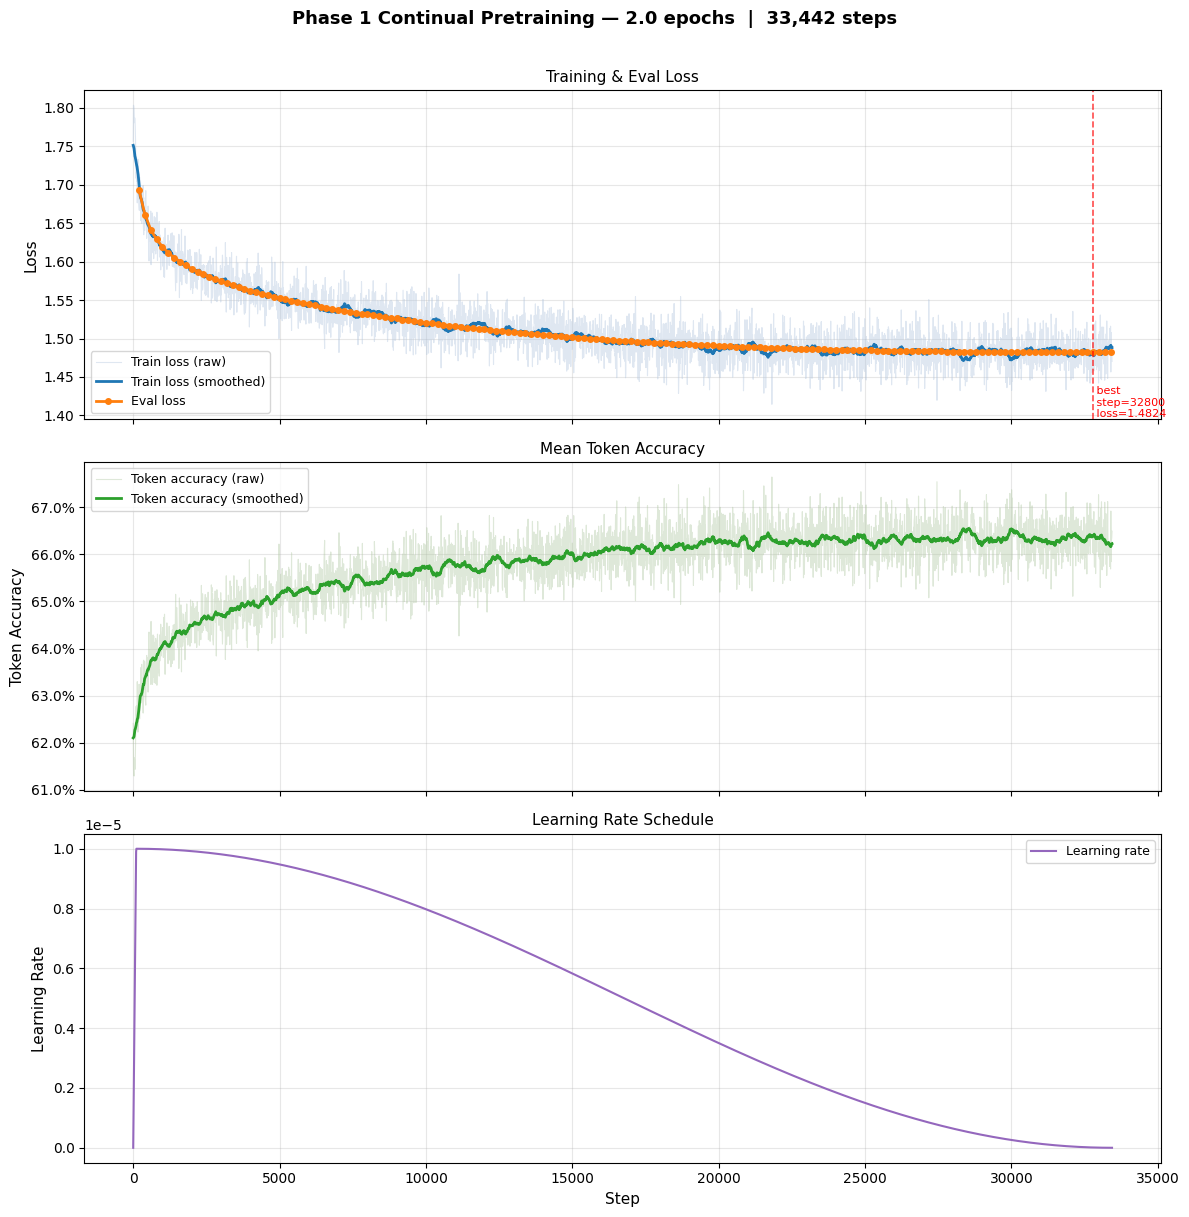

In [5]:
data=load_history("./checkpoints/stage1-lora/trainer_state.json")
plot(
    data=load_history("./checkpoints/stage1-lora/trainer_state.json"),
    output_path="./training_curves.png"
    )

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_path = "./checkpoints/stage1-merged"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForCausalLM.from_pretrained(model_path, torch_dtype=torch.bfloat16, device_map="auto")

prompts = [
    "3GPP TS 38.214 defines the procedure for",
    "In 5G NR, the physical downlink shared channel (PDSCH) is used for",
    "The UE shall initiate a random access procedure when",
]

for prompt in prompts:
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=80, do_sample=False)
    print(f"\nPrompt: {prompt}")
    print(f"Output: {tokenizer.decode(outputs[0], skip_special_tokens=True)}")

/users/m/modinan/miniconda3/envs/aiml_torch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 338/338 [00:00<00:00, 1190.44it/s]
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.



Prompt: 3GPP TS 38.214 defines the procedure for
Output: 3GPP TS 38.214 defines the procedure for the UE to report the CSI-RS based RLM and SSB based RLM and RLM quality evaluation and report the evaluation result in a periodicity of 10 ms. The UE shall use the CSI-RS configured for RLM as the CSI-RS for RLM measurement. The UE shall use the SSB configured for RLM as the SSB for RLM measurement. The


Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.



Prompt: In 5G NR, the physical downlink shared channel (PDSCH) is used for
Output: In 5G NR, the physical downlink shared channel (PDSCH) is used for the transmission of user data. The PDSCH is mapped to the physical resource blocks (PRBs) in the frequency domain. The mapping of the PDSCH to the PRBs is performed by the physical downlink shared channel (PDCCH) in the time domain. The PDCCH is transmitted on the physical downlink control channel (PDCCH) in the time domain. The

Prompt: The UE shall initiate a random access procedure when
Output: The UE shall initiate a random access procedure when the received MAC control element commands the transmission of a random access preamble. The UE shall choose a random access preamble and a corresponding PRACH configuration randomly, uniformly at random over all the PRACH configurations in the configured PRACH set for this RA type, as specified in [3].

The UE shall transmit the random access preamble and wait for a random access response fro

: 

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_path = "./checkpoints/stage2-merged"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForCausalLM.from_pretrained(model_path, dtype=torch.bfloat16, device_map="auto")

PROMPT_TEMPLATE = "### Instruction:\n{instruction}\n\n### Response:\n"

prompts = [
    "What is the purpose of the random access procedure in 5G NR?",
    "Explain the difference between FR1 and FR2 frequency ranges in 5G.",
    "What does CSI-RS stand for and what is it used for?",
    "Summarize the role of the AMF in the 5G core network.",
]

for prompt in prompts:
    input_text = PROMPT_TEMPLATE.format(instruction=prompt)
    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=150,
            do_sample=False,
            eos_token_id=tokenizer.eos_token_id,
        )
    response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    print(f"\nQ: {prompt}")
    print(f"A: {response}")
    print("-" * 60)